In [1]:
import h5py
import numpy as np
from scipy import signal, ndimage
import sys
import os
import matplotlib.pyplot as plt
sys.path.append(os.path.abspath("../src"))

from alignment import CrossCorrelationAlignment, TomoConsistencyAlignment, TomoConsistencyConfig, VerticalAlignment, VerticalAlignmentConfig
import utilities as utils

TomoPy links to compiled components which are installed separately and loaded using ctypes.util.find_library(). A required library, tomo-recon, was not found.
No module named 'recast_tomo'


#### Load data

In [2]:
# folder = '/mnt/share/ALC_ptychography_alignment/Experimental/connor_wright'
# folder = '/dls/i13-1/data/2025/cm40629-5/processing/ptycho-tomo_alignment/i14_example_dataset/'
folder = '/dls/i13-1/data/2025/cm40629-5/processing/ptycho-tomo_alignment/example_dataset/'
# folder = '/dls_sw/i13-1/scripts/cSAXS_matlab_tomo_shared/'
file = folder + 'example_data.mat' #'/example_data.h5' #'/scan_275019_275199_tomo_complex.nxs'
# img, theta, _ = utils.io_tools.load_data(file, data_key= '/entry1/instrument/detector/data', 
#                                          angle_key = '/entry1/sample/rotation_angle')
img, theta, _ = utils.io_tools.load_data(file, data_key='stack_object', angle_key = 'theta')
# img = img.transpose((1,2,0)) # transpose to shape [Ny, Nx, Nangles]

projections shape: (284, 335, 316)
angles shape: (316,)


Here we remove one duplicate angle, this should be replaced with code to automatically find the angles to remove

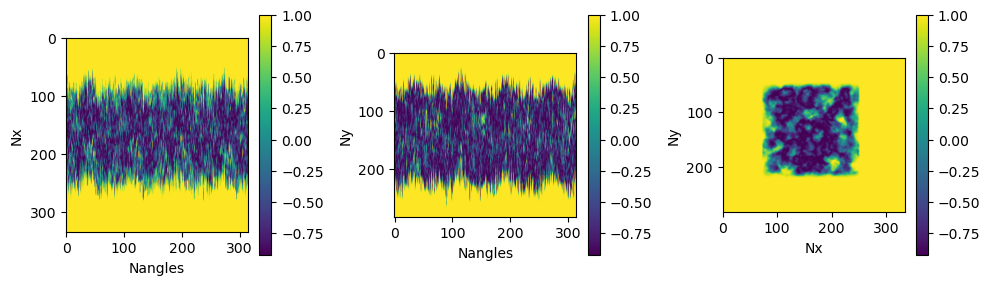

In [3]:
# img = img[:,:,:]
# theta = theta[:]
img = img[:,:,1:]
theta = theta[1:]
utils.display_tools.plot_3axes(np.real(img), array_name='', data_order=['Ny', 'Nx','Nangles'])

Next choose a range to crop in vertical (Ny) and horizontal (Nx)

In [4]:
[Ny, Nx, Nangles] = img.shape
Ny_start = 25 #83 #
Ny_stop = Ny-Ny_start
Nx_start = 25 #66 #
Nx_stop = Nx-Nx_start

object_ROI = [np.ceil(np.arange(Ny_start,Ny_stop)), np.ceil(np.arange(Nx_start,Nx_stop))]

width_sinogram = np.ceil(len(object_ROI[1])/32)*32
Nlayers = np.floor(len(object_ROI[0])/32)*32
Nroi = [len(object_ROI[0]), len(object_ROI[1])]

object_ROI = [object_ROI[0][int(np.ceil(Nroi[0]/2)-1)] + np.arange(1-Nlayers/2, Nlayers/2+1),
              object_ROI[1][int(np.ceil(Nroi[1]/2)-1)] + np.arange(1-width_sinogram/2, width_sinogram/2+1)]

Ny_start = int(object_ROI[0][0])
Ny_stop = int(object_ROI[0][-1]+1)
Nx_start = int(object_ROI[1][0])
Nx_stop = int(object_ROI[1][-1]+1)

theta_order = np.argsort(theta)
theta_sorted = theta[theta_order]
inv_order = np.argsort(theta_order)

utils.display_tools.plot_crop(np.angle(img[:,:,theta_order]), Nx_start, Nx_stop, Ny_start, Ny_stop, Nangles)

interactive(children=(IntSlider(value=157, description='slice_idx', max=314), Output()), _dom_classes=('widget…

#### Quick cross-correlation alignment

This could be replaced with a different method

In [5]:
# xcorr = CrossCorrelationAlignment()
# # shift_correlation = xcorr.run_alignment(img[Ny_start:Ny_stop,Nx_start:Nx_stop,:], theta)
# shift_correlation = xcorr.run_alignment(img[object_ROI[0].astype(int),:,:][:,object_ROI[1].astype(int),:], theta)

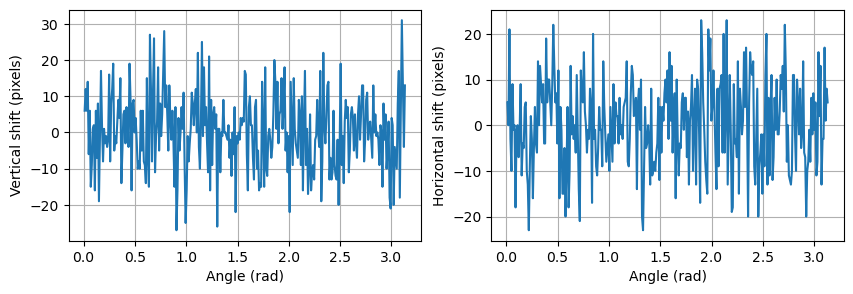

In [6]:
from alignment.CrossCorrelationAlignment import MatlabStyleCrossCorrelationAlignment

aligner = MatlabStyleCrossCorrelationAlignment()
total_shift, variation, variation_aligned = aligner.run_alignment(
    img[object_ROI[0].astype(int),:,:][:,object_ROI[1].astype(int),:],
    theta,
    roi=(slice(None), slice(None)),
    binning=4,
    max_iter=3,
    filter_pos=1.0,
    filter_data=0.01,
)

If we're satisfied with the alignment save the calculated values to the total_shifts array. 

We can choose to apply the shifts we found to only horizontal OR both

In [7]:
shift_total = np.zeros((Nangles,2))

shift_total[:,0] = shift_total[:,0] + total_shift[theta_order,0] # only apply horizontal
# shift_total[:,0] = shift_total[:,0] + shift_correlation[:,0] # only apply horizontal
# shift_total = shift_total + shift_correlation # apply both

In [8]:
### TODO
# Apply cross correlation with utils.imshift_linear

#### Vertical alignment

First we do a 2D phase unwrapping - this requires complex data so if we do not have complex data, skip the unwrapping step and try the vertical alignment directly on the image

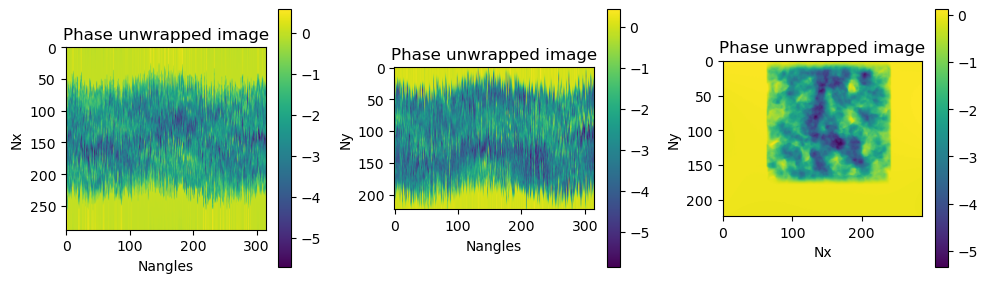

In [9]:
phase, residuals = utils.phase_tools.unwrap2D_fft2(img[object_ROI[0].astype(int),:,:][:,object_ROI[1].astype(int),:][:,:,theta_order], 
                                                   empty_region=(50,50))
phase=phase.real

utils.display_tools.plot_3axes(phase, 'Phase unwrapped image', ['Ny','Nx','Nangles'])

Run the vertical mass alignment code. It first runs a quick cross-correlation estimate and then uses vertical mass fluctuation to iteratively improve on the result.
Here we run the code with default config values but they can be edited by redifining any variable as shown below.

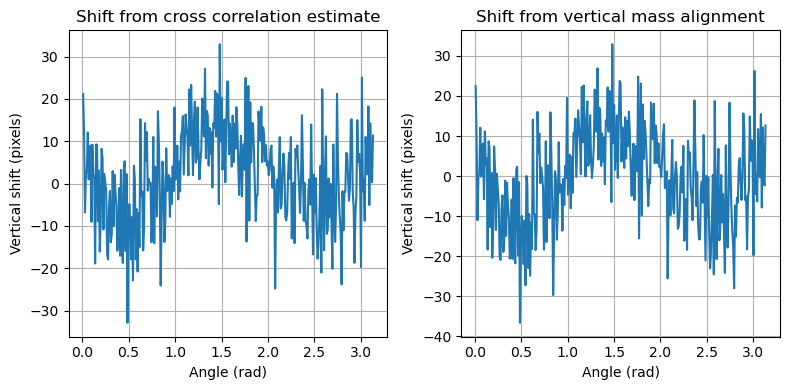

In [10]:
config = VerticalAlignmentConfig(
    data_filter = 0.01,
    iterations = 1000) # over-ride defaults here if needed
va = VerticalAlignment(config)
shift_vertical = va.run_alignment(phase, residuals, theta[theta_order])

If we're satisfied with the alignment, save the calculated values to the total_shifts array. 

Here we only apply shifts to the vertical

In [11]:
shift_total[:,1] = shift_total[:,1] + shift_vertical

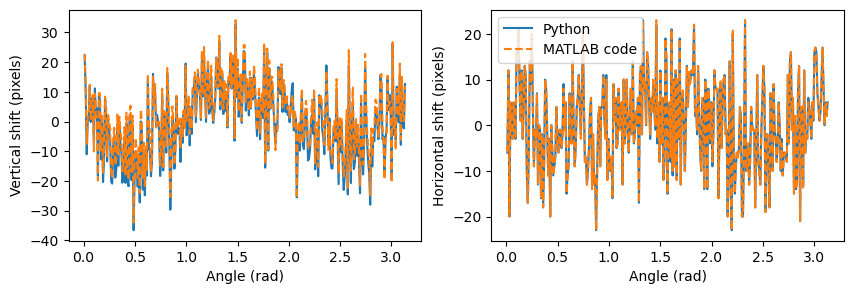

In [12]:
# Debug only - comparison with matlab (cSAXS example dataset)
shifts_xcorr = np.loadtxt('/dls/i13-1/data/2025/cm40629-5/processing/ptycho-tomo_alignment/example_dataset/cross_correlation_matlab.csv', 
                          delimiter = ',') 
shifts_VMF = np.loadtxt('/dls/i13-1/data/2025/cm40629-5/processing/ptycho-tomo_alignment/example_dataset/VMF_matlab.csv', 
                        delimiter = ',')
ind_sort = np.loadtxt('/dls/i13-1/data/2025/cm40629-5/processing/ptycho-tomo_alignment/example_dataset/ind_sort.csv', 
                        delimiter = ',')

horiz_shifts = shifts_xcorr[ind_sort.astype(int)-1,0]
verti_shifts = shifts_xcorr[ind_sort.astype(int)-1,1] + shifts_VMF[ind_sort.astype(int)-1]

# shifttt[:,0] = np.fromstring(horiz_shifts, sep=' ')
# shifttt[:,1] = np.fromstring(verti_shifts, sep=' ')

import matplotlib.pyplot as plt
plt.figure(figsize=[10,3])
plt.subplot(121),plt.plot(theta[theta_order], shift_total[:,1], label='Python')
plt.subplot(121),plt.plot(theta[theta_order], verti_shifts, '--', label='MATLAB code') 
plt.ylabel('Vertical shift (pixels)'), plt.xlabel('Angle (rad)')
plt.subplot(122),plt.plot(theta[theta_order], shift_total[:,0], label='Python')
plt.subplot(122),plt.plot(theta[theta_order], horiz_shifts, '--', label='MATLAB code')
plt.ylabel('Horizontal shift (pixels)'), plt.xlabel('Angle (rad)')
plt.legend()

In [13]:
# Debug only - comparison with matlab (C. Wright I14 sample)
# shifttt = np.zeros((180,2))
# horiz_shifts = "34	53	71	53	46	60	49	59	94	53	49	42	16	10	2	-1	3	7	-7	-10	-12	16	-10	-10	15	23	12	16	-1	7	1	20	5	-15	-13	-20	-43	-32	-31	-22	-28	-41	-30	-17	-10	-14	5	16	1	8	-3	11	9	2	-10	-14	-4	1	-3	-12	0	2	4	23	-4	17	17	15	-3	16	13	-8	1	20	24	12	-4	12	21	26	26	17	39	37	22	10	33	38	37	25	28	25	34	37	36	25	20	19	14	21	6	29	11	5	12	18	23	22	4	14	5	2	-7	-17	4	10	5	-23	-7	-16	-5	-14	-15	-12	-30	-2	8	37	9	-13	-25	-1	-20	-38	-12	-42	-38	-30	-14	-50	-29	-18	-39	-16	-18	-24	-30	-17	-9	-5	-18	-8	-18	-21	-27	-14	-34	-17	-8	-1	11	15	33	50	45	32	55	43	52	71	65	55	78	82	86	81	88	87	102	99"
# verti_shifts = "15.413752	18.869938	17.952105	15.048748	15.317489	16.457272	12.412716	12.346809	10.830973	11.337815	10.017136	5.8283844	10.083050	5.8169851	6.0416551	4.2934666	5.6583614	5.9371600	4.0354943	5.7538233	3.3005543	3.7650852	5.2703390	1.8591213	5.4564781	2.8896022	2.1997428	-0.17467356	-1.9699535	0.87871838	-3.2357435	0.76823330	-2.5602198	-2.1836128	-1.9600611	-4.5140209	-0.36251450	-3.0791235	-4.6122513	-9.9342089	-7.4991922	-5.3061371	-6.2287035	-5.0426693	-5.3855629	-7.9935055	-7.9635601	-7.0324230	-7.1765413	-6.2677298	-8.1166430	-9.2110443	-12.414388	-11.159865	-10.753753	-8.2610178	-13.170260	-11.250447	-10.745543	-14.356794	-11.571807	-11.877501	-12.783373	-13.843271	-14.373517	-10.941634	-14.464982	-12.502694	-13.538865	-12.422956	-11.257554	-13.799178	-10.734569	-10.189597	-12.750818	-9.7716684	-11.705909	-9.7415876	-11.212492	-10.909909	-12.516102	-14.289781	-8.9605494	-10.871581	-12.549095	-11.684525	-11.340709	-8.3016386	-9.5872774	-9.6175232	-4.7576141	-8.8119392	-7.6817207	-5.5180302	-4.1780596	-6.6357822	-6.3888206	-9.7493811	-7.3984365	-8.9965677	-4.9184933	-6.0479937	-6.1219254	-8.5863094	-4.4894323	-6.1594181	-5.1547985	-1.6491451	-2.7983265	-4.8097448	-5.3291540	0.41888046	-2.4759121	-4.6141396	-0.88960218	2.6166501	-2.0870996	-0.31212139	-2.6427526	-2.8247013	-1.2003055	-1.7152777	0.36425114	2.0175438	4.4538631	5.2944336	5.1687856	6.4964113	7.2222686	6.8367939	8.5167551	4.5047450	6.3769894	6.7455845	6.9169655	10.386265	8.1206379	8.1449308	10.452344	11.728489	9.8030329	10.273876	13.346823	12.488131	9.9812059	10.827835	15.084057	11.828949	19.741692	16.388168	16.768448	17.337341	15.531812	16.133751	15.302582	18.366550	17.546852	22.554668	17.627645	20.540474	22.700542	20.932266	21.294281	23.177410	25.027546	26.459126	23.972595	27.682163	26.186676	22.967850	26.703648	26.649876	28.135220	29.545984	28.637554	31.443890	31.050766	25.562595	29.057617	29.617386"
# shifttt[:,0] = np.fromstring(horiz_shifts, sep=' ')
# shifttt[:,1] = np.fromstring(verti_shifts, sep=' ')

# import matplotlib.pyplot as plt
# plt.figure(figsize=[10,3])
# plt.subplot(121),plt.plot(theta, shift_total[:,1], label='Python')
# plt.subplot(121),plt.plot(theta, shifttt[:,1], '--', label='MATLAB code') 
# plt.ylabel('Vertical shift (pixels)'), plt.xlabel('Angle (rad)')
# plt.subplot(122),plt.plot(theta, shift_total[:,0], label='Python')
# plt.subplot(122),plt.plot(theta, shifttt[:,0], '--', label='MATLAB code')
# plt.ylabel('Horizontal shift (pixels)'), plt.xlabel('Angle (rad)')
# plt.legend()

Apply shift total to the original image

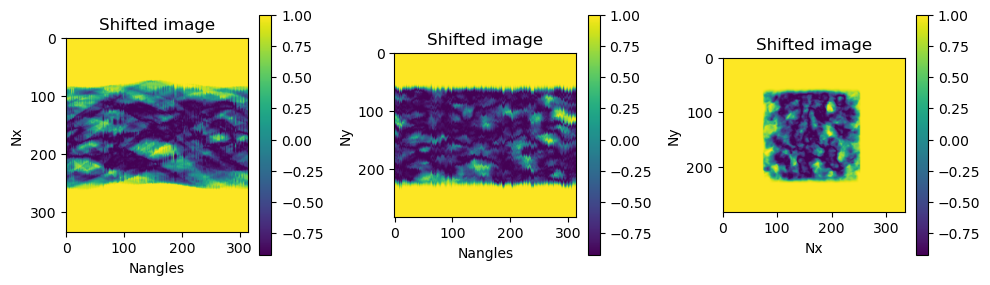

In [14]:
help_shift_total = np.copy(shift_total[inv_order,:])

for m in range(shift_total.shape[0]):
    img[:,:,m] = np.roll(img[:,:,m],(int(help_shift_total[m,0]), int(help_shift_total[m,1])),axis=(1,0)) 
utils.display_tools.plot_3axes(img[:,:,theta_order].real, 'Shifted image', ['Ny', 'Nx', 'Nangles'])

#### Tomoconsistency alignment

First get the phase gradient and calculate weights

In [15]:
# get the phase gradient
img_grad = utils.phase_tools.get_phase_gradient_1D(img, ax=1)[object_ROI[0].astype(int),:,:][:,object_ROI[1].astype(int),:][:,:,theta_order] # apply on the full image then re-crop
[Ny, Nx, Nangles] = img_grad.shape

high_pass_filter = 0.01
# include the effect of high pass filter into the weights 
size = np.maximum(3, int(np.ceil(high_pass_filter * Nx)))
gauss_window = signal.windows.gaussian(size, std = size/6)
hanning_window = signal.windows.hann(3)
ker = gauss_window.reshape(-1,1) * hanning_window

# relevance weights -> remove effect of potential residues / phase jumps 
ker2 = ker[np.newaxis,:,:]
convolution_result = ndimage.convolve((np.abs(img_grad) > 2).astype(np.float32), ker2.astype(np.float32), mode = 'constant', cval = 0.0)
weights_find_shift = np.maximum(0,1-convolution_result)

We can further reduce the vertical range here if needed

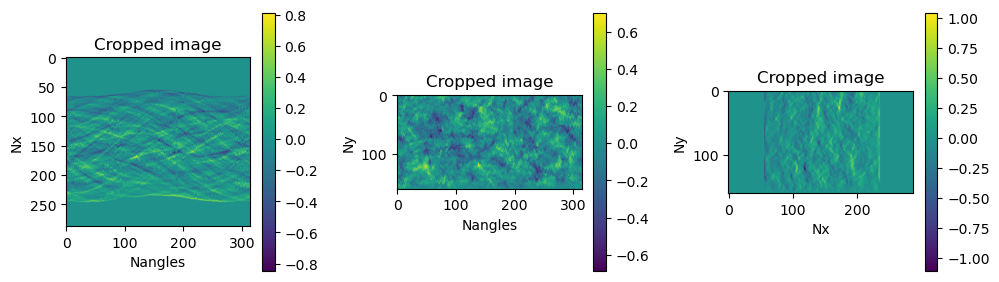

In [16]:
vert_range = (31, Ny-33)

utils.display_tools.plot_3axes(img_grad.real[vert_range[0]:vert_range[1],:,:], 'Cropped image', ['Ny', 'Nx', 'Nangles'])

ROI = (
    slice(int(vert_range[0]), int(vert_range[1])),
    slice(None)
)

Setup the alignment code with default values

In [17]:
config = TomoConsistencyConfig(
    max_iterations = 500,
    step_relaxation = 0.5,
    high_pass_filter = 0.01,
    min_step_size = 0.01,
    unwrap_data_method = 'fft_1d',
    plot_interactive = True,
    center_reconstruction = True,
    apply_mask = False,
    momentum_acceleration = True,
    align_horizontal = True,
    align_vertical = False,
    apply_positivity = True)

aligner = TomoConsistencyAlignment(config)


Run the TomoConsistency code with different binning levels

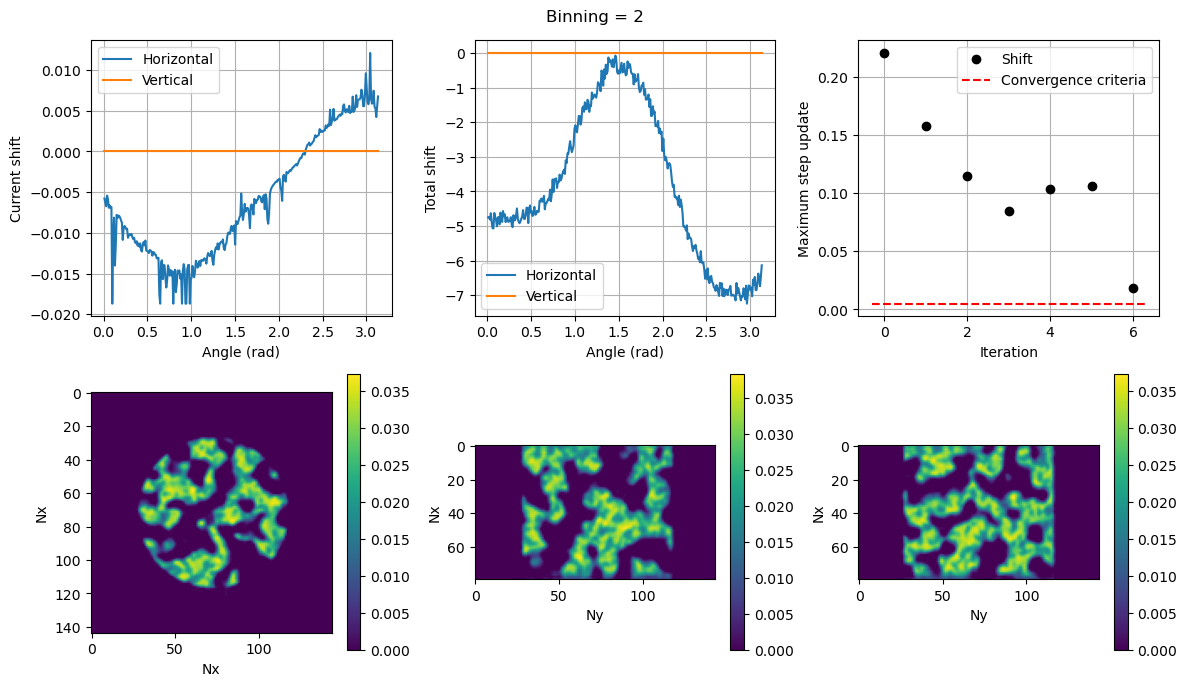

Iteration 6 time 1.34 seconds[71.99775678 71.9889515 ]
[72.0032816  71.99344274]
shift update shape: (315, 2)
Total time: 0.64 minutes


In [18]:
import time
t0 = time.time()

# Loop over different binning levels
bin_levels = [ 4, 2] 

shift_tomoconsistency = np.zeros((Nangles,2))
for binning in bin_levels:

    # Apply ROI and binning
    sinogram = utils.shift_tools.imshift_generic(img_grad, shift=np.zeros((Nangles,2)), Npix = None, affine_matrix = None, smooth = 5, 
                                        ROI = ROI, downsample = binning, interp_method = 'fft', interp_sign = 1)
    

    weights_find_shift = np.maximum(0,1-convolution_result)
    weights_find_shift = utils.shift_tools.imshift_generic(weights_find_shift, shift=np.zeros((Nangles,2)), Npix = None, affine_matrix = None, smooth = 0, 
                                        ROI = ROI, downsample = binning, interp_method = 'linear', interp_sign = 1)
    
    shift_tomoconsistency, _, rec, _ = aligner.run_alignment(sinogram, theta[theta_order], weights_find_shift, shift_tomoconsistency, binning)

print(f'\rTotal time: {(time.time() - t0)/60:.2f} minutes')

In [19]:
help_shift_total[:,0] = help_shift_total[:,0] + shift_tomoconsistency[inv_order,0] # only apply horizontal
# shift_total = shift_total + shift_tomoconsistency # apply both

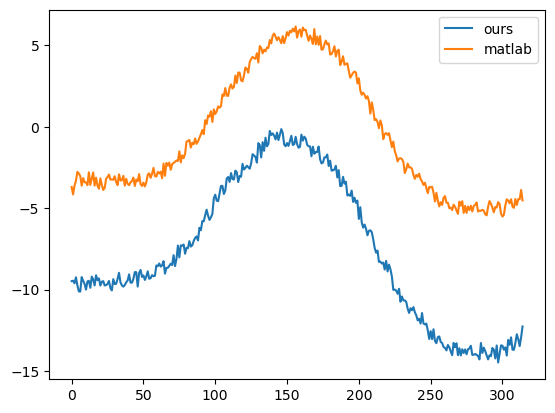

In [20]:
tomocon_matlab = np.loadtxt('/dls/i13-1/data/2025/cm40629-5/processing/ptycho-tomo_alignment/example_dataset/tomoconsistency_shift.csv', 
                        delimiter = ',')

tomocon_shifts_matlab = tomocon_matlab[ind_sort.astype(int)-1,0]

plt.figure()
plt.plot(shift_tomoconsistency[:,0])
plt.plot(tomocon_shifts_matlab)
plt.legend(['ours', 'matlab'])

In [53]:
from dataclasses import dataclass
import numpy as np
import time
from scipy.optimize import fmin
from scipy.signal.windows import tukey
import matplotlib.pyplot as plt
from IPython.display import clear_output

def radtap(X, Y, tappix, zerorad):
    tau = 2 * tappix  # period of cosine function
    R = np.sqrt(X**2 + Y**2)
    taperfunc = 0.5 * (1 + np.cos(2 * np.pi * (R - zerorad - tau/2) / tau))
    taperfunc = ((R > zerorad + tau/2).astype(float) + taperfunc * (R <= zerorad + tau/2))
    taperfunc = taperfunc * (R >= zerorad)
    return taperfunc

def fract_hanning(outputdim, unmodsize=0):

    if outputdim < unmodsize:
        raise ValueError("outputdim must be >= unmodsize")

    if unmodsize < 0:
        unmodsize = 0

    N = np.arange(outputdim)
    Nc, Nr = np.meshgrid(N, N)

    if unmodsize == 0:
        out = ((1 + np.cos(2 * np.pi * Nc / outputdim))* (1 + np.cos(2 * np.pi * Nr / outputdim))/ 4)
    else:
        edge = (unmodsize - 1) // 2
        out = (1+ np.cos(2 * np.pi* (Nc - edge)/ (outputdim + 1 - unmodsize))) / 2
        if edge > 0:
            out[:, :edge] = 1
        start2 = edge + outputdim + 3 - unmodsize - 1
        out[:, start2:] = 1
        out2 = (1+ np.cos(2 * np.pi* (Nr - edge)/ (outputdim + 1 - unmodsize))) / 2
        if edge > 0:
            out2[:edge, :] = 1
        out2[start2:, :] = 1
        out *= out2

    return out


def fract_hanning_pad(outputdim, filterdim=None, unmodsize=0):

    if filterdim is None:
        filterdim = outputdim
    if outputdim < unmodsize:
        raise ValueError("outputdim must be >= unmodsize")
    if outputdim < filterdim:
        raise ValueError("filterdim must be <= outputdim")
    if unmodsize < 0:
        unmodsize = 0

    out = np.zeros((outputdim, outputdim))
    start = round(outputdim / 2 + 1 - filterdim / 2) - 1
    stop = round(outputdim / 2 + 1 + filterdim / 2 - 1)
    out[start:stop, start:stop] = np.fft.fftshift(fract_hanning(filterdim, unmodsize))
    out = np.fft.fftshift(out)

    return out


def apply_3D_apodization(
        tomogram,
        rad_apod,
        axial_apod=None,
        radial_smooth=None):

    Npix = tomogram.shape[0]

    if tomogram.ndim == 2:
        Nlayers = 1
    else:
        Nlayers = tomogram.shape[2]

    if radial_smooth is None:
        radial_smooth = Npix / 10

    circulo = None

    # radial apodization
    if rad_apod is not None:
        xt = np.arange(-Npix / 2, Npix / 2)
        X, Y = np.meshgrid(xt, xt)
        radial_smooth = max(radial_smooth, 1)
        circulo = (1 - radtap(X,Y,radial_smooth,round(Npix / 2 - rad_apod - radial_smooth))).astype(np.float32)
        if tomogram.ndim == 2:
            tomogram = tomogram * circulo
        else:
            tomogram = tomogram * circulo[:, :, None]

    # axial apodization
    if (axial_apod is not None and Nlayers > 1):
        filters = fract_hanning_pad(Nlayers,Nlayers,max(0,round(Nlayers - 2 * axial_apod)))
        filters = np.fft.ifftshift(filters[:, 0])
        tomogram = tomogram * filters.reshape(1, 1, Nlayers)
    return tomogram, circulo

from utilities import phase_tools, recon_tools, shift_tools, sino_tools

In [90]:
max_iterations= 200
step_relaxation =0.5
high_pass_filter= 0.01
min_step_size: float = 0.01
unwrap_data_method= 'fft_1d'
plot_interactive =True
center_reconstruction= True
apply_mask= False
momentum_acceleration = True
align_horizontal= True
align_vertical = False
apply_positivity = True

# Loop over different binning levels
bin_levels = [ 4] 
binning = bin_levels[0]
shift_tomoconsistency = np.zeros((Nangles,2))

In [91]:
[Nlayers, Nw, Nangles] = img_grad.shape

weights_find_shift = np.maximum(0,1-convolution_result)
if weights_find_shift.all() == 1:
    weights_find_shift = []
    

In [92]:
# Apply ROI and binning
sinogram = utils.shift_tools.imshift_generic(img_grad, shift=np.zeros((Nangles,2)), Npix = None, affine_matrix = None, smooth = 5, 
                                             ROI = ROI, downsample = binning, interp_method = 'fft', interp_sign = 1)

if weights_find_shift:
    weights_find_shift = utils.shift_tools.imshift_generic(weights_find_shift, shift=np.zeros((Nangles,2)), Npix = None, 
                                                           affine_matrix = None, smooth = 0, ROI = ROI, downsample = binning, 
                                                           interp_method = 'linear', interp_sign = 1)

[Nlayers, width_sinogram, _] = sinogram.shape

# taper weights at the edges to avoid edge artefacts dominating the shift estimate
win = tukey(width_sinogram, 0.2).reshape(1, 1, width_sinogram)
if Ny > 10 and align_vertical:
    win = tukey(Nlayers, 0.2).reshape(Nlayers, 1, 1) * win

Npix = [width_sinogram, width_sinogram, Nlayers]
rotation_centre = np.array([Ny, Nx], dtype=np.float32) / 2

if not weights_find_shift: 
    weights_find_shift = 1

[_, circulo] = apply_3D_apodization(np.zeros(Npix),0,0,5)


In [93]:
shift_upd_all = np.empty((max_iterations, Nangles, 2), dtype=np.float32)
shift_upd_all[0,:,:] = 0.0
shift_total = np.zeros((Nangles, 2), dtype=np.float32)
err = np.empty((1,Nangles), dtype=np.float32)

In [94]:
# transpose the sinogram to the [Ny, Nangles, Nx] order required by astra
sinogram = sinogram.transpose((0, 2, 1))

if weights_find_shift and (weights_find_shift is not 1):
    weights_find_shift = weights_find_shift.transpose((0, 2, 1))

In [102]:
# Phase unwrapping (this is done inside the iterations in Matlab)
if unwrap_data_method is not None:
    if unwrap_data_method == 'fft_1d':
        sinogram_shifted = -phase_tools.unwrap2D_fft(sinogram, axis=2, boundary=None)[0]
    else:
        raise ValueError("Supported unwrapping methods are None or 'fft_1d'")

(<Axes: >,
 <matplotlib.colorbar.Colorbar at 0x7f59d2c99af0>)

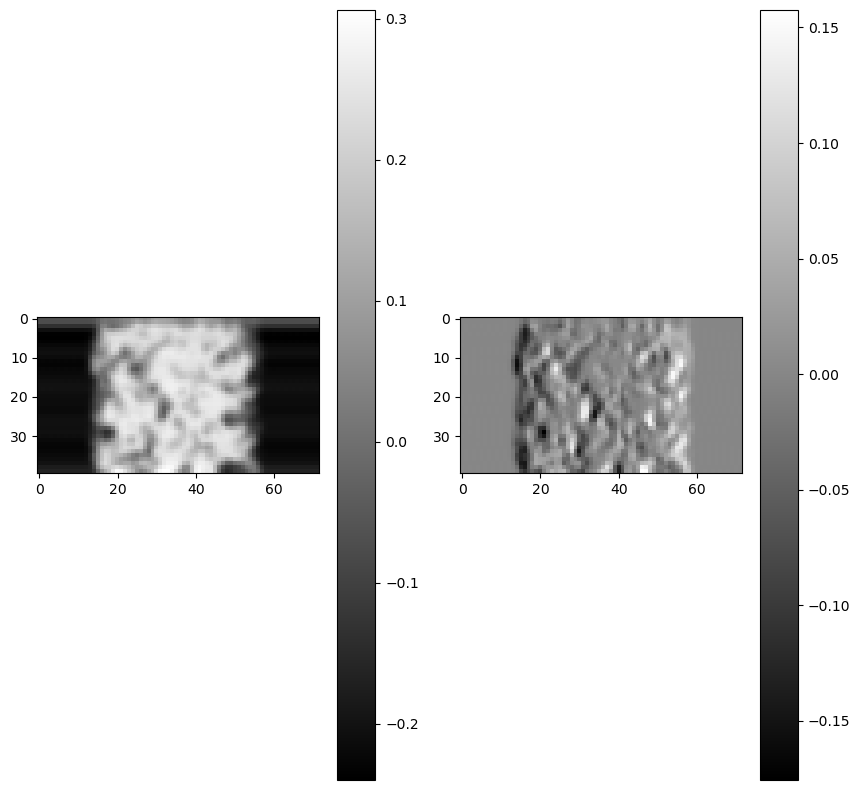

In [109]:
plt.figure(figsize=[10,10])
plt.subplot(121),plt.imshow(sinogram_shifted[:,99,:],cmap='gray'),plt.colorbar()
plt.subplot(122),plt.imshow(sinogram[:,99,:],cmap='gray'),plt.colorbar()

In [ ]:
weights_find_shift = np.maximum(0, weights_find_shift * win)

dtheta = (theta[-1] - theta[0]) / (len(theta) - 1) if len(theta) > 1 else 1.0
weights_fbp = np.full(len(theta), dtheta, dtype=np.float32)

shift_total = optimal_shift / binning
shift_history = []
shift_velocity = np.zeros((Nangles, 2))

In [ ]:


iterations = []
maxvals = []
plt.figure()
for ii in range(self.config.max_iterations):
    t0 = time.time()

    # FBP
    vol_geom, proj_geom = recon_tools.init_astra_vec(Nx, Ny, theta, shift_total)
    rec = recon_tools.FBP_astra(sinogram_shifted, vol_geom, proj_geom, weights_fbp)

    # Mask
    # should always apply circulo mask! 
    if self.config.apply_mask: 
        rec = recon_tools.apply_circular_mask(rec, 0.9)

    # Remove negative values
    if self.config.apply_positivity:
        rec = np.maximum(0, rec)

    # Centering
    if self.config.center_reconstruction:
        rec_center = sino_tools.centering_reconstruction(rec)
        print(rec_center)
        
        if ii == 0:
            rec_center_0 = [rec.shape[2]/2,rec.shape[1]/2]

        shift_rec = -0.5*(rec_center - rec_center_0)
        rec = shift_tools.imshift_fft_2dax(rec, shift_rec[0], shift_rec[1], axis=(2,1))

        # debugging: check if shift has moved the rec to the centre correctly
        rec_center = sino_tools.centering_reconstruction(rec)
        print(rec_center)
                
    # Get reprojection
    sinogram_model = recon_tools.get_projections(rec, vol_geom, proj_geom)

    # Calculate optimal shift
    # MASS = np.median(sinogram_shifted * np.mean(abs(sinogram_shifted), axis=(0,1)))
    MASS = np.median(np.mean(abs(sinogram_shifted), axis=(0,1)))
    shift_upd, err = self.find_optimal_shift_ax(sinogram_model, sinogram_shifted, 
                                                weights_find_shift, MASS, 
                                                self.config.high_pass_filter, 
                                                self.config.unwrap_data_method, 
                                                align_horizontal=self.config.align_horizontal, 
                                                align_vertical=self.config.align_vertical, 
                                                axes=(0,2,1))
    

    shift_upd = np.minimum(0.5, np.abs(shift_upd)) * np.sign(shift_upd) * self.config.step_relaxation
    
    # Limit the shift size and apply a step relaxation factor
    #max_step = min(np.quantile(abs(shift_upd), 0.99), 0.5); 
    #shift_upd = np.minimum(max_step, abs(shift_upd))*np.sign(shift_upd)*self.config.step_relaxation
    
    # Update shift history
    shift_history.append(shift_upd) # reshape?
    # max_update = np.quantile(abs(shift_upd), 0.995)

    # Use momentum to accelerate convergence, but only once updates have mostly converged
    pre_momentum_max_update = np.quantile(np.abs(shift_upd[:, 0]), 0.995)
    if self.config.momentum_acceleration == True and ii > 2 and pre_momentum_max_update * binning < 0.5:
        
        shift_upd, shift_velocity = self.add_momentum_horizontal(shift_history, shift_velocity)

    # Apply a median shift in the vertical direction only
    shift_upd[:, 1] -= np.median(shift_upd[:, 1])
    
    max_step = np.minimum(np.quantile(abs(shift_upd), 0.99), 0.5)
    shift_upd = np.minimum(max_step, abs(shift_upd)) * np.sign(shift_upd) 

    shift_total = shift_total + shift_upd
    print('shift update shape:', shift_upd.shape)
    
    #position update smoothing?

    # Check the maximal step update and stop if it's below the stopping criterion
    # max_update = np.quantile(abs(shift_upd), 0.995)
    max_update = np.max(np.quantile(np.abs(shift_upd),0.995,axis=0))
    
    if max_update*binning < self.config.min_step_size:
        break

    if self.config.plot_interactive:
        iterations.append(ii)
        maxvals.append(max_update)
        self.plot_alignment(shift_upd, shift_total, rec, theta, iterations, maxvals, binning)
    else:
        print(f"\rMaximum step update: {max_update*binning:.2f} px stopping criterion: {self.config.min_step_size:4.2g} px" , end="", flush=True)
    print(f'\rIteration {str(ii)} time {time.time()-t0:.2f} seconds', end="", flush=True)

optimal_shift = shift_total*binning

if self.config.plot_interactive is False:
    shift_history = np.array(shift_history)
    plt.figure(figsize=(10,5))
    for i in range(shift_history.shape[0]):
        plt.plot(i, np.quantile(abs(shift_history[i, :, :]), 0.995), 'ok')
        plt.ylabel("Maximum step update")
        plt.xlabel("Iteration")
    plt.show()
    

In [ ]:
    def plot_alignment(self, shift_upd, shift_total, rec, theta, iterations, maxvals, binning):
        
        clear_output(wait=True)  # clear previous figure
        fig, axs = plt.subplots(2, 3, figsize=(12, 7))

        plt.suptitle("Binning = " + str(binning))

        ax = axs[0,0]
        ax.plot(theta, shift_upd)
        ax.set_ylabel('Current shift')
        ax.set_xlabel('Angle (rad)')
        ax.legend(['Horizontal', 'Vertical'])
        ax.grid()

        ax = axs[0,1]
        ax.plot(theta, shift_total)
        ax.set_ylabel('Total shift')
        ax.set_xlabel('Angle (rad)')
        ax.legend(['Horizontal', 'Vertical'])
        ax.grid()

        ax = axs[0,2]
        ax.plot(iterations, maxvals, 'ok')
        ax.plot(ax.get_xlim(), [self.config.min_step_size/binning, self.config.min_step_size/binning], '--r')
        ax.set_ylabel('Maximum step update')
        ax.set_xlabel('Iteration')
        ax.legend(['Shift', 'Convergence criteria'])
        ax.grid()

        ax = axs[1,0]
        im=ax.imshow(rec[rec.shape[0]//2,:,:])
        fig.colorbar(im, ax=ax)
        ax.set_ylabel('Nx')
        ax.set_xlabel('Nx')

        ax = axs[1,1]
        im=ax.imshow(rec[:,rec.shape[1]//2,:])
        ax.set_ylabel('Nx')
        ax.set_xlabel('Ny')

        fig.colorbar(im, ax=ax)
        ax = axs[1,2]
        im=ax.imshow(rec[:,:,rec.shape[2]//2])
        fig.colorbar(im, ax=ax)
        ax.set_ylabel('Nx')
        ax.set_xlabel('Ny')

        plt.tight_layout()
        plt.show()

    def find_optimal_shift_ax(self, sinogram_model, sinogram, weights, MASS, high_pass_filter, unwrap_data_method, align_horizontal=True, align_vertical=False, axes=(0, 1, 2)):
        """
        Parameters
            axes Specify order of [Ny, Nx, Nangles] for sinogram_model and sinogram. Default matlab order is [Ny, Nx, Nangles] = (0, 1, 2), default astra order is [Ny, Nangles, Nx] = (0, 2, 1)"""

        Ny_ax = axes[0]
        Nx_ax = axes[1]
        Nangles_ax = axes[2]

        shift_x = np.zeros(sinogram_model.shape[Nangles_ax], dtype=np.float32)
        shift_y = np.zeros(sinogram_model.shape[Nangles_ax], dtype=np.float32)
        
        resid_sino = sinogram_model - sinogram
        # apply high pass filter to get rid of phase artefacts
        resid_sino = phase_tools.imfilter_high_pass_1d(resid_sino, Nx_ax, high_pass_filter)
        
        if unwrap_data_method.lower() == 'none':
            resid_sino = phase_tools.imfilter_high_pass_1d(resid_sino, ax=Nangles_ax, sigma=high_pass_filter, padding=0)
        
        # Horizontal alignment 
        if align_horizontal:      
            dX = phase_tools.get_img_grad_filtered_ax(sinogram_model, axis=Ny_ax, high_pass_filter=high_pass_filter, smooth_win=5, axes=axes)
            if unwrap_data_method.lower() == 'none':
                dX = phase_tools.imfilter_high_pass_1d(dX, ax=Nangles_ax, sigma=high_pass_filter, padding=0)
            
            numerator = np.sum(weights * dX * resid_sino, axis=(Ny_ax, Nx_ax))
            # if np.mean(numerator) < 0.01:
            #     numerator[:] = 0
            denominator = np.sum(weights * dX**2, axis=(Ny_ax, Nx_ax)) # sum2 and mean 2????????????????
            shift_x = -numerator / denominator

        
        # Vertical alignment
        if align_vertical:
            dY = phase_tools.get_img_grad_filtered_ax(sinogram_model, axis=Nx_ax, high_pass_filter=high_pass_filter, smooth_win=5, axes=axes)
            if unwrap_data_method.lower() == 'none':
                dY = phase_tools.imfilter_high_pass_1d(dY, ax=Nangles_ax, sigma=high_pass_filter, padding=0)

            numerator = np.sum(weights * dY * resid_sino, axis=(Nx_ax, Ny_ax))
            # if np.mean(numerator) < 0.01:
            #     numerator[:] = 0
            denominator = np.sum(weights * dY**2, axis=(Nx_ax, Ny_ax))
            shift_y = -numerator / denominator
        
        # Combine shifts
        shift = np.stack([shift_x, shift_y], axis=-1)

        # Check for NaNs
        if np.isnan(shift).any():
            print("Warning: Alignment failed, estimated shift is NaN")

        # Compute error
        err = np.sqrt(np.mean((weights * resid_sino)**2, axis=(Ny_ax, Nx_ax))) / MASS

        return shift, err

    def add_momentum_horizontal(self, shift_history, velocity_map):

        # get a subset of the shift history as a numpy array
        momentum_memory = 2
        shift_memory = np.stack(shift_history[-(momentum_memory+1):], axis=0)
        
        # this is the current shift we want to update with momentum
        shift = shift_memory[-1].copy()

        # only apply momentum in horizontal direction
        axis = 0 
        
        if np.all(shift[:, axis] == 0):
            return shift, velocity_map
        
        # find correlation between current shift and previous shifts in the horizontal direction
        C = np.zeros(momentum_memory)
        for ii in range(momentum_memory):
            prev_shift = shift_memory[ii][:, axis]
            if np.all(prev_shift == 0):
                C[ii] = 0
            else:
                # correlation coefficient
                C[ii] = np.corrcoef(shift[:, axis], prev_shift)[0,1]

        # minimise the difference between the current shift and the exponentially decayed previous shifts
        def loss(x):
            return np.linalg.norm(C - np.exp(-x * np.arange(momentum_memory, 0, -1)))

        decay = fmin(loss, 0.0, disp = False)[0]

        # scaling parameters
        alpha = 2.0
        gain = 0.5
        friction = np.minimum(np.maximum(alpha * decay, 0), 1)

        # update velocity map
        velocity_map[:,axis] = (1 - friction) * velocity_map[:, axis] + shift[:, axis]

        # update shift using velocity map
        shift[:, axis] = (1 - gain) * shift[:, axis] + gain * velocity_map[:, axis]

        return shift, velocity_map    

#### Perform the reconstruction ourselves

We can plot the reconstruction again

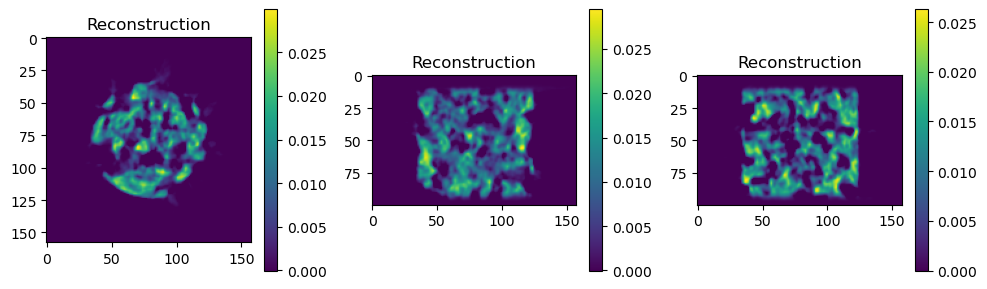

In [17]:
utils.display_tools.plot_3axes(rec, 'Reconstruction')

Or run the reconstruction directly using the shifts we found from the alignment:
- Apply shifts and whatever binning or ROI we want, or just reconstruct everything
- Apply phase unwrapping
- Run the reconstruction
- Apply a circular mask and remove negative values

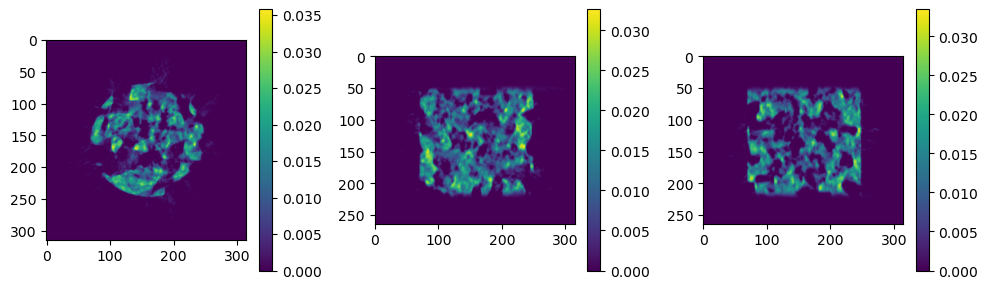

In [18]:
# bin or apply ROI or use full data
# img_grad = utils.phase.get_phase_gradient_1D(img, ax=1) # re-run phase gradient calculation if you want to skip the initial cropping as well 

sinogram = utils.shift_tools.imshift_generic(img_grad, shift=shift_tomoconsistency, Npix = None, affine_matrix = None, smooth = 5, 
                                        ROI = None, downsample = 1, interp_method = 'fft', interp_sign = 1) # can include ROI here too
                                        
import astra

# transpose for astra
sinogram = sinogram.transpose((0, 2, 1))
[Ny, Nangles, Nx] = sinogram.shape

# apply phase unwrapping
phase = -utils.phase_tools.unwrap2D_fft(sinogram, axis=2, boundary=None)[0]

# run reconstruction
dtheta = (theta[-1] - theta[0]) / (len(theta) - 1) if len(theta) > 1 else 1.0
weights_fbp = np.full(len(theta), dtheta, dtype=np.float32)

vol_geom, proj_geom = utils.recon_tools.init_astra(Nx, Ny, theta)
rec = utils.recon_tools.FBP_astra(phase, vol_geom, proj_geom, weights_fbp)

# apply circular mask
rec = utils.recon_tools.apply_circular_mask(rec, 0.9)

# remove negative values
rec = np.maximum(0, rec)

utils.display_tools.plot_3axes(rec)

#### Fourier ring correlation

Get two reconstructions for the Fourier ring correlation. Split data and run reconstruction

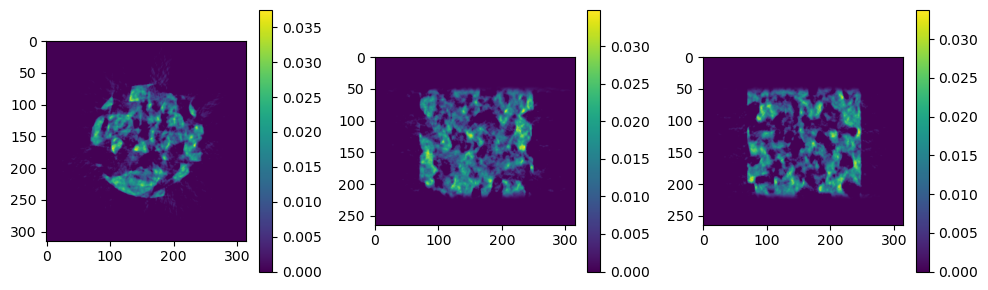

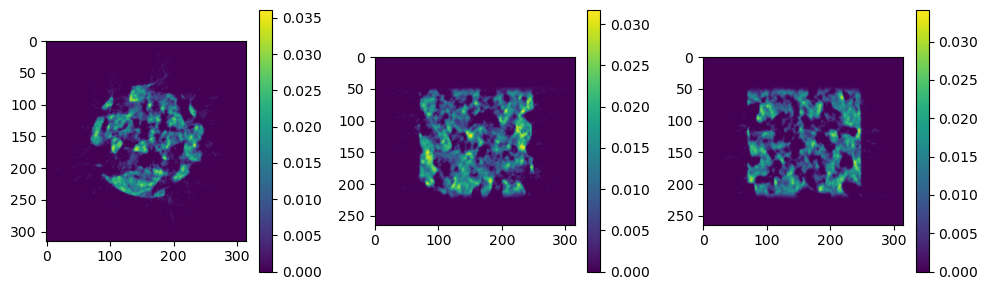

In [19]:
rec_list = []
for i in range(2):
    sinogram_half = phase[:, i::2, :]
    theta_half = theta[i::2]

    [Ny, Nangles, Nx] = sinogram_half.shape

    # run reconstruction
    dtheta = (theta_half[-1] - theta_half[0]) / (len(theta_half) - 1) if len(theta_half) > 1 else 1.0
    weights_fbp = np.full(len(theta_half), dtheta, dtype=np.float32)

    Nz = Nx
    vol_geom = astra.create_vol_geom(Nx, Nz, Ny)

    # Projection geometry (3D parallel beam)
    proj_geom = astra.create_proj_geom(
        'parallel3d',
        1,  # detector pixel size in x
        1,  # detector pixel size in y   
        Ny,          
        Nx,          
        theta_half
    )

    rec = utils.recon_tools.FBP_astra(sinogram_half, vol_geom, proj_geom, weights_fbp)

    # apply circular mask
    rec = utils.recon_tools.apply_circular_mask(rec, 0.9)

    # remove negative values
    rec = np.maximum(0, rec)

    rec_list.append(rec)
utils.display_tools.plot_3axes(rec_list[0])
utils.display_tools.plot_3axes(rec_list[1])

Run 2D Fourier ring correlation

Spatial resolution is roughly  60.19108280254776  -  66.54929577464787  nm.


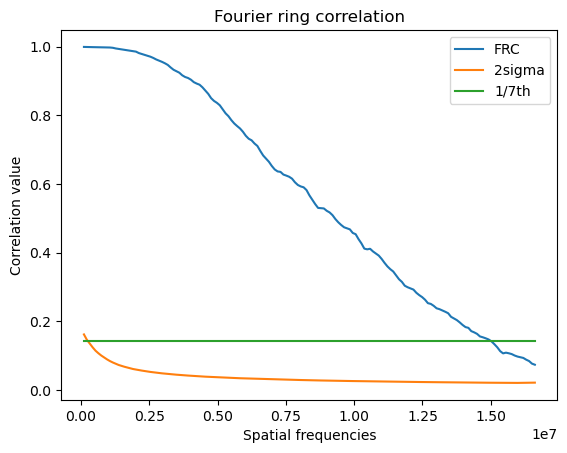

In [20]:
utils.quality_metrics.fourier_ring_correlation(rec_list[0][rec_list[0].shape[0]//2,:,:], rec_list[1][rec_list[1].shape[0]//2,:,:])

#### Save

Uncomment below to save the shifts as csv and the reconstruction as a tiff stack

In [ ]:
# np.savetxt('shift_total.csv', shift_total, delimiter=',', header='horizontal,vertical', comments='')

In [ ]:
# save_dir = 'reconstruction'
# os.makedirs(save_dir, exist_ok=True)

# for i in range(rec.shape[0]):
#     tifffile.imwrite(os.path.join(save_dir, f'slice_{i:04d}.tif'), rec[i])

# The Aug 26 refactor 

## cross correlation cemetery

In [163]:
object_0 = np.asarray(img[object_ROI[0].astype(int),:,:][:,object_ROI[1].astype(int),:])
if np.isrealobj(object_0):
    raise ValueError('Complex object expected.')

roi = (slice(None), slice(None))
binning=4 
max_iter = 1
filter_pos = Nangles/4
filter_data = 0.01
illum_sum = None

theta = np.asarray(theta, dtype=float)
theta_order = np.argsort(theta)
theta_sorted = theta[theta_order]
object_sorted = object_0[:, :, theta_order]

y_slice, x_slice = roi
object_roi = object_0[y_slice, x_slice, :]
Ny, Nx, Nangles = object_roi.shape

if illum_sum is None:
    illum_sum = np.ones((Ny, Nx), dtype=float)
#     weights = np.ones((Ny, Nx), dtype=float)
# else:
#     illum_sum = np.asarray(illum_sum)

weights = illum_sum[y_slice, x_slice] / (illum_sum[y_slice, x_slice] + 1e-1 * np.max(illum_sum))

In [164]:
### get variation field
# variation = self._get_variation_field(object_roi, binning, weights)

from scipy.ndimage import convolve

dX = convolve(object_roi, [[[-1],[1]]], mode='constant', cval=0.0)
dY = convolve(object_roi, [[[-1]],[[1]]], mode = 'constant', cval=0.0)

# dX = np.diff(object_roi, axis=0, prepend=object_roi[0:1, :, :])
# dY = np.diff(object_roi, axis=1, prepend=object_roi[:, 0:1, :])

In [165]:
variation = np.sqrt(np.abs(dX) ** 2 + np.abs(dY) ** 2)
variation = variation * np.abs(object_roi)

In [166]:
variation[[0, -1], :, :] = variation[[1, -2], :, :]
variation[:, [0, -1], :] = variation[:, [1, -2], :]

In [167]:
if weights is not None:
    weights = np.asarray(weights, dtype=float)
    varwei = variation * weights[:, :, None]
    mean_variation = np.mean(np.mean(varwei,axis=0, keepdims=1), axis=1, keepdims=1) / np.mean(weights)
    varmwei = (variation - mean_variation) ** 2 * weights[:, :, None]
    dev_variation = np.sqrt(np.mean(np.mean(varmwei,axis=0,keepdims=1),axis=1,keepdims=1)) / np.mean(weights)
    variation = np.minimum(variation, mean_variation + dev_variation)
    # mean_variation = np.sum(variation * weights[:, :, None]) / np.sum(weights)
    # dev_variation = np.sqrt(np.sum((variation - mean_variation) ** 2 * weights[:, :, None]) / np.sum(weights))
    # variation = np.minimum(variation, mean_variation + dev_variation)

[[0.03607344 0.07000168 0.05340052]
 [0.0562731  0.07403778 0.05424444]
 [0.13096325 0.06098824 0.09367553]
 [0.18140403 0.0877338  0.07134151]]


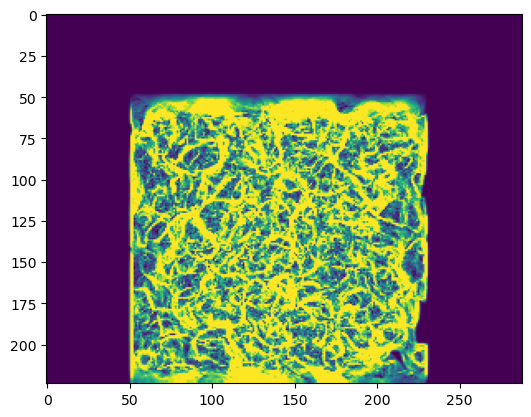

In [168]:
plt.imshow(variation[:,:,300])
print(variation[100:104,100:103,300])

In [169]:
boundary_correctiontest = gaussian_filter(np.ones_like(variation[:, :, 0],dtype=complex), sigma=(2 * binning, 2 * binning), truncate=2.0, mode='constant',cval=0.0)
print(boundary_correctiontest)

[[0.27661988+0.j 0.3037006 +0.j 0.330154  +0.j ... 0.330154  +0.j
  0.3037006 +0.j 0.27661988+0.j]
 [0.3037006 +0.j 0.33343249+0.j 0.36247563+0.j ... 0.36247563+0.j
  0.33343249+0.j 0.3037006 +0.j]
 [0.330154  +0.j 0.36247563+0.j 0.39404854+0.j ... 0.39404854+0.j
  0.36247563+0.j 0.330154  +0.j]
 ...
 [0.330154  +0.j 0.36247563+0.j 0.39404854+0.j ... 0.39404854+0.j
  0.36247563+0.j 0.330154  +0.j]
 [0.3037006 +0.j 0.33343249+0.j 0.36247563+0.j ... 0.36247563+0.j
  0.33343249+0.j 0.3037006 +0.j]
 [0.27661988+0.j 0.3037006 +0.j 0.330154  +0.j ... 0.330154  +0.j
  0.3037006 +0.j 0.27661988+0.j]]


In [170]:
if binning > 1:
    sigma = (2 * binning, 2 * binning, 0)
    variation = gaussian_filter(variation, sigma=sigma, truncate=2.0, mode='constant',cval=0.0)
    boundary_correction = gaussian_filter(np.ones_like(variation[:, :, 0],dtype=complex), sigma=(2 * binning, 2 * binning), truncate=2.0, mode='constant',cval=0.0)
    variation = variation / boundary_correction[:, :, None]
    variation = variation[::binning, ::binning, :]
            

[[0.12082611 0.12481481 0.12733387]
 [0.11907157 0.12242702 0.12445065]
 [0.11600457 0.11911252 0.12087943]
 [0.11315038 0.11652143 0.11843656]
 [0.11098646 0.11436345 0.1164834 ]]


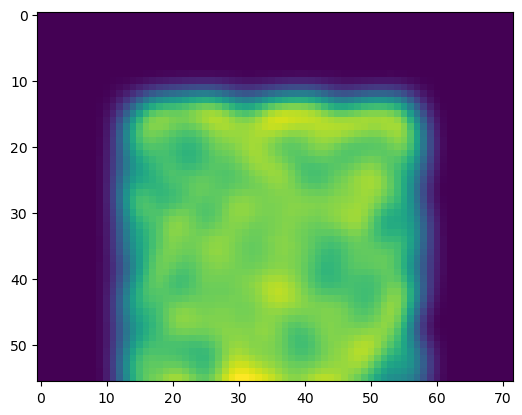

In [171]:
variation = np.real(variation)
nyy, nxx, n_angless = variation.shape
plt.imshow(variation[:,:,300])
print(variation[20:25,20:23,200])

[[0.1148861  0.11095856 0.10868651]
 [0.11403181 0.10982544 0.10729652]
 [0.1147722  0.11088491 0.10833921]
 [0.11724653 0.11463037 0.11278749]
 [0.1186286  0.11789882 0.11749534]]


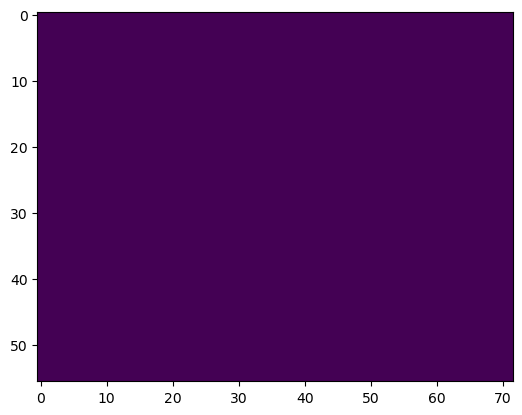

In [172]:
total_shift_sorted = np.zeros((Nangles, 2), dtype=float)

### filtered fft
# fvar = self._filtered_fft(variation, total_shift_sorted, filter_data)
ny, nx, _ = variation.shape
var = utils.shift_tools.imshift_fft(variation, total_shift_sorted)

print(var[20:25,20:23,300])
plt.imshow(var[:,:,300] - variation[:,:,300])

In [173]:
window = np.outer(tukey(ny, alpha=0.3), tukey(nx, alpha=0.3))
print(window[0:5,0:5])
print(np.mean(var))

[[0.         0.         0.         0.         0.        ]
 [0.         0.00077351 0.00302722 0.00656644 0.01108543]
 [0.         0.00298323 0.0116752  0.02532504 0.04275358]
 [0.         0.00631258 0.02470498 0.05358835 0.09046753]
 [0.         0.01028458 0.04024987 0.08730726 0.14739159]]
0.06114029993822896


In [174]:
var = var - np.mean(var)
var *= window[:, :, None]

(<Axes: >, <matplotlib.image.AxesImage at 0x7f5f3462f620>)

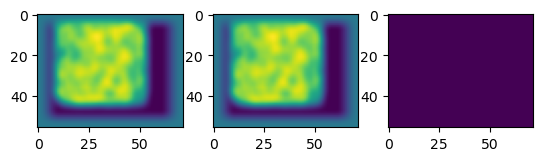

In [189]:
test_ref = np.copy(var[:,:,theta_order])
test_align = np.copy(var[:,:,np.roll(theta_order,-1)])

plt.figure()
plt.subplot(131),plt.imshow(test_ref[:,:,156])
plt.subplot(132),plt.imshow(test_align[:,:,155])
plt.subplot(133),plt.imshow(test_ref[:,:,156] - test_align[:,:,155])

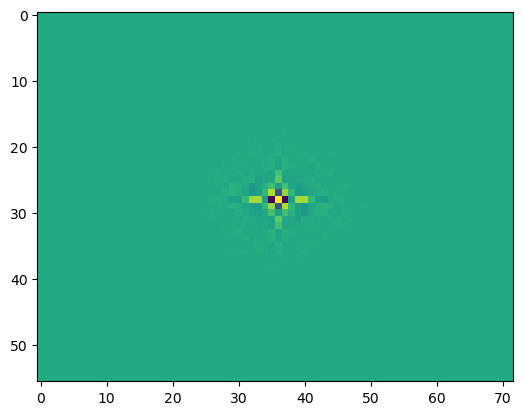

In [190]:
var = np.fft.fft2(var,axes=(0,1)) 
# print(test[20:25,20:23,300])
var.shape
plt.imshow(np.real(np.fft.fftshift(var[:,:,300])))
##### at this point values differ from matlab

In [191]:
yy, xx = np.meshgrid(np.arange(-nx//2,nx//2), np.arange(-ny//2,ny//2), indexing='ij')
radius_sq = xx ** 2 + yy ** 2
mean_dim = np.mean([ny, nx])

In [192]:
spectral_filter = np.fft.fftshift(np.exp(1/(-(radius_sq / ((mean_dim * filter_data) ** 2))))).T

In [193]:
fvar = var * spectral_filter[:,:,None]

In [137]:
if filter_data > 0:
    yy, xx = np.meshgrid(np.arange(-nx//2,nx//2), np.arange(-ny//2,ny//2), indexing='ij')
    radius_sq = xx ** 2 + yy ** 2
    mean_dim = np.mean([ny, nx])
    spectral_filter = np.fft.fftshift(np.exp(1/(-(radius_sq / ((mean_dim * filter_data) ** 2))))).T
    fvar = var * spectral_filter[:,:,None]
else:
    fvar = var

In [194]:
relative_shifts = np.zeros_like(total_shift_sorted)

frame_ref = fvar[:,:,theta_order]
frame_align = fvar[:,:,np.roll(theta_order,-1)]

#### check whether this is right
print(frame_ref.shape)

(56, 72, 315)


In [195]:
o1.shape

(56, 72, 315)

In [199]:
o1 = np.asarray(frame_ref)
o2 = np.asarray(frame_align)

if o1.shape != o2.shape:
    raise ValueError(f'o1 and o2 must have the same shape; got {o1.shape} and {o2.shape}.')

nx, ny = o1.shape[:2]

xcorr = np.fft.fftshift(np.abs(np.fft.ifft2(o1 * np.conj(o2), axes=(0,1))), axes=(0,1))

(<matplotlib.image.AxesImage at 0x7f5f3539e960>,
 <matplotlib.colorbar.Colorbar at 0x7f5f35385a60>)

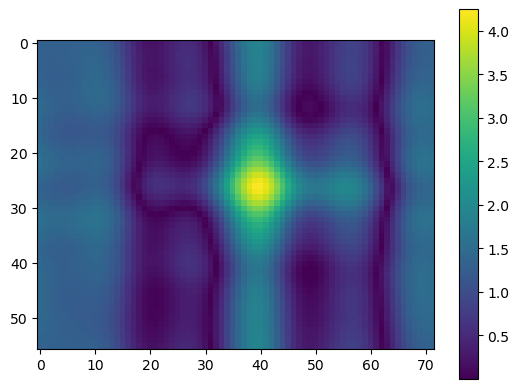

In [202]:
plt.imshow(xcorr[:,:,0]),plt.colorbar()

In [234]:
from scipy.signal import convolve as convn

win = 5
kernel = np.ones((win, win, 1), dtype=float)

# max_val = np.max(xcorr)
# mask = np.isclose(xcorr, max_val)

mask = np.equal(xcorr, np.max(xcorr,axis=(0,1),keepdims=True)).astype(int)
mask = convn(mask, kernel, mode='same') > 0.1

In [237]:
xcorr = np.where(mask, xcorr, np.nan)
xcorr = np.maximum(0.0, xcorr - np.nanmin(xcorr,axis=(0,1),keepdims=True))
xcorr = np.where(mask, xcorr, 0.0)
xcorr = np.power(xcorr / np.max(xcorr,axis=(0,1),keepdims=True), 2)
xcorr = np.maximum(0.0, xcorr - 0.5) ** 2

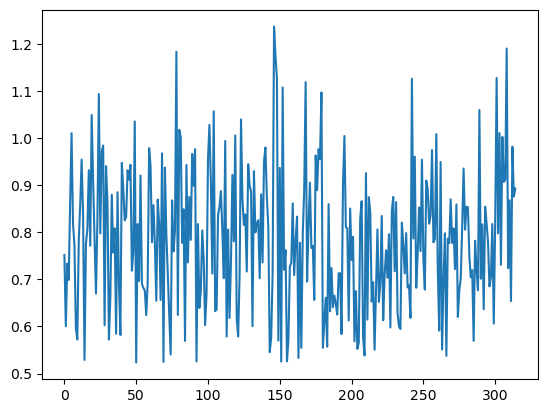

In [245]:
mass = np.sum(xcorr, axis=(0,1))
# if mass == 0:
    # return np.array([0.0, 0.0], dtype=float)
plt.plot(mass)

In [253]:
x_idx = np.arange(xcorr.shape[1])
y_idx = np.arange(xcorr.shape[0])
print(x_idx.shape)
print(y_idx.shape)
print(np.sum(xcorr, axis=1, keepdims=True).shape)
print(np.sum(xcorr, axis=0, keepdims=True).shape)


(72,)
(56,)
(56, 1, 315)
(1, 72, 315)


In [254]:
test = np.sum(xcorr, axis=1, keepdims=True) * y_idx[:, None, None]
print(test.shape)

(56, 1, 315)


In [275]:
x_idx = np.arange(xcorr.shape[1])
y_idx = np.arange(xcorr.shape[0])

x_center = np.sum(np.sum(xcorr, axis=0, keepdims=True) * x_idx[None, :, None],axis=1) / mass - (xcorr.shape[1] // 2) - 1
y_center = np.sum(np.sum(xcorr, axis=1, keepdims=True) * y_idx[:, None, None],axis=0) / mass - (xcorr.shape[0] // 2) - 1

shift = np.array([x_center[0,:], y_center[0,:]], dtype=float).T

In [277]:
# Matlab uses circshift(relative_shifts,1).
relative_shifts = np.roll(shift, 1, axis=0)

In [289]:
# Robust magnitude cap for a single iteration, matching the Matlab idea.
# Clipping policy will be finalized later; for now this keeps the update bounded.
max_shift = [max(10.0, (3.0 * np.median(np.abs(relative_shifts - np.median(relative_shifts,axis=0)),axis=0))[0]),
             max(10.0, (3.0 * np.median(np.abs(relative_shifts - np.median(relative_shifts,axis=0)),axis=0))[1])]
relative_shifts = np.minimum(max_shift, np.abs(relative_shifts)) * np.sign(relative_shifts)